# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [182]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [183]:
pip install scikit-learn

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 4.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 4.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.3 MB 4.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [82]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df_raw = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df_raw):,} | Columnas: {len(df_raw.columns)}')

Filas: 1,067,371 | Columnas: 8


In [83]:
df_raw.to_pickle('online_retail.pkl')
#df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [84]:
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [85]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [86]:
df_raw.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

## 3. Calidad de datos

In [87]:
## chequear nulos y duplicados
def info_to_dataframe(df):
    info_dict = {
        "Column": df.columns.tolist(),
        "No Nulos": df.count().values,
        "Tipo de Dato": df.dtypes.values
    }

    info_df = pd.DataFrame(info_dict)
    info_df["Porcentaje Nulos"] = ((df.isnull().sum() / len(df)) * 100).values
    return info_df

In [88]:
info_df = info_to_dataframe(df_raw)
info_df[info_df["Porcentaje Nulos"] > 0]

,Column,No Nulos,Tipo de Dato,Porcentaje Nulos
2,Description,1062989,object,0.410541
6,Customer ID,824364,float64,22.766873


In [89]:
## La variable Description se puede eliminar puesto que StockCode cumple la misma función de identificación del producto y no contiene nulos
df_no_description = df_raw.drop("Description", axis=1)
info_df = info_to_dataframe(df_no_description)
info_df[info_df["Porcentaje Nulos"] > 0]

,Column,No Nulos,Tipo de Dato,Porcentaje Nulos
5,Customer ID,824364,float64,22.766873


In [90]:
## La variable Customer Id, en cambio, no tiene otra sustituyente y es crucial para el propósito del modelo así que se buscan otras alternativas
## Recuperar Customer Id de facturas con mismo Invoice y Customer ID no nulos

## Comprobar que cada factura solo tiene un Customer ID distinto
invoice_customer = (
    df_no_description.groupby("Invoice")["Customer ID"]
      .nunique(dropna=False)
)

invoice_customer.describe()
## max = 1 implica que solo hay un tipo de Customer ID distinto por Invoice, incluyendo los nulos
## Es decir, al agrupar por Invoice solo existen las opciones de que tenga Customer Id nulo o no nulo, pero no ambos

count    53628.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Customer ID, dtype: float64

In [91]:
# Se analizó la posibilidad de recuperar estos identificadores a partir del número de factura (Invoice), comprobando si existían facturas parcialmente identificadas.
# Sin embargo, las facturas con Customer ID nulo no contienen ninguna línea asociada a un identificador válido, por lo que no es posible reconstruir esta información de forma fiable.

# Dado que el objetivo del proyecto es predecir la probabilidad de recompra a nivel cliente, es imprescindible disponer de un identificador para relacionar las transacciones con cada
# cliente.
# Por este motivo, los registros sin Customer ID son eliminados del análisis y del entrenamiento del modelo.

rows_before = len(df_no_description)

null_customers = df_no_description["Customer ID"].isna().sum()

print(f"Filas totales: {rows_before}")
print(f"Filas eliminadas: {null_customers}")

df_clean = df_no_description.dropna(subset=["Customer ID"])

print(f"Filas actuales: {len(df_clean)}")

Filas totales: 1067371
Filas eliminadas: 243007
Filas actuales: 824364


In [92]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Quantity     824364 non-null  int64         
 3   InvoiceDate  824364 non-null  datetime64[us]
 4   Price        824364 non-null  float64       
 5   Customer ID  824364 non-null  float64       
 6   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(1)
memory usage: 50.3+ MB


In [93]:
# Revisar si el resto de variables contienen valores invalidos (precios negativos, strings vacíos...)

# Strings vacíos en Country
print(f"Nº de strings vacias en Country: {len(df_clean[df_clean["Country"] == ""])}")

# Valores negativos en Quantity (pueden deberse a cancelaciones o devoluciones)
print("\nValor mínimo de Quantity:", df_clean["Quantity"].min())
# Comprobamos si todos los valores negativos son cancelaciones
negative_qty = df_clean[df_clean["Quantity"] < 0]
print("\nCorrespondencia de con facturas canceladas: \n", negative_qty["Invoice"].astype(str).str.startswith("C").value_counts()) # Los valores negativos coinciden con las cancelaciones

# Precios inválidos
print("\nValor mínimo de Price:", df_clean["Price"].min()) # No hay precios negativos, pero si igual a 0 (posiblemente por regalos o rembolsos)

# Recogemos los StockCodes con precio igual a 0
zero_price_codes = df_clean.loc[df_clean["Price"] == 0, "StockCode"].unique()
print("Nº de productos con precio 0:", len(zero_price_codes))

# Miramos si existe una relación consistente entre el codigo y el precio para comprobar si el precio 0 se trata de un error recuperable por referencia en otras facturas
code_price_analysis = (
    df_clean[df_clean["StockCode"].isin(zero_price_codes)]
    .groupby("StockCode")["Price"]
    .agg(
        min_price="min",
        max_price="max",
        n_prices="nunique"
    )
    .sort_values("n_prices", ascending=False)
)

# Visualizamos una porción de los datos
code_price_analysis.head(5)
# Comprobamos que la mayoria de códigos contienen una variedad de precios distintos por lo que es probable que los precios fijados a 0 no se traten de un error
# sino de una decision lógica, ya sea como promoción, regalo u otras acciones ya que no existe una relación código-precio estable

# También es posible la estrategia de sustituir los 0 por la media o la moda entre los precios históricos del código de producto
# Pero suponiendo que el precio fijado a 0 no se trata de un error, es posible que inventar estas ventas perjudique el entrenamiento del modelo
# De modo que la decisión tomada consiste en mantener estos precios a 0 entendiendolos como registros voluntarios

Nº de strings vacias en Country: 0

Valor mínimo de Quantity: -80995

Correspondencia de con facturas canceladas: 
 Invoice
True    18744
Name: count, dtype: int64

Valor mínimo de Price: 0.0
Nº de productos con precio 0: 61


,min_price,max_price,n_prices
StockCode,,,
M,0.0,38970.00,377
48185,0.0,15.79,12
22690,0.0,15.79,10
47566,0.0,10.79,9
22385,0.0,4.13,8


In [94]:
# Finalmente convertimos los datos a su tipo correcto o preferido

# Invoice y StockCode a tipo string (Pueden contener carácteres no numéricos)
df_clean["Invoice"] = df_clean["Invoice"].astype("string")
df_clean["StockCode"] = df_clean["StockCode"].astype("string")

# Customer ID de float64 a int64 (estaba establecido como float por defecto por la presencia de nulos)
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

# Country de tipo str a string (aunque es prácticamente el mismo tipo, se transforma por consistencia de tipos)
df_clean["Country"] = df_clean["Country"].astype("string")

df_clean.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  string        
 1   StockCode    824364 non-null  string        
 2   Quantity     824364 non-null  int64         
 3   InvoiceDate  824364 non-null  datetime64[us]
 4   Price        824364 non-null  float64       
 5   Customer ID  824364 non-null  int64         
 6   Country      824364 non-null  string        
dtypes: datetime64[us](1), float64(1), int64(2), string(3)
memory usage: 50.3 MB


In [95]:
# Finalmente tratamos los duplicados

# Nº de filas duplicadas
n_duplicates = df_clean.duplicated().sum()
print(f"Nº de filas duplicadas: {n_duplicates}")
print(f"Porcentaje: {n_duplicates/len(df_clean)*100:.2f}%")

# Recuento de duplicados por fila
duplicate_groups = (
    df_clean.groupby(list(df_clean.columns))
    .size()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

duplicate_groups.head(10)

Nº de filas duplicadas: 26481
Porcentaje: 3.21%


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,count
533141,555524,22698,1,2011-06-05 11:37:00,2.95,16923,United Kingdom,20
533140,555524,22697,1,2011-06-05 11:37:00,2.95,16923,United Kingdom,12
394215,537224,70007,1,2010-12-05 16:24:00,1.65,13174,United Kingdom,10
689888,572861,22775,12,2011-10-26 12:46:00,1.25,14102,United Kingdom,8
747889,578289,23395,1,2011-11-23 14:07:00,3.75,17841,United Kingdom,6
389638,536749,22174,2,2010-12-02 13:49:00,1.65,17976,United Kingdom,6
99701,502660,17021,6,2010-03-25 17:18:00,0.30,13187,United Kingdom,6
394143,537224,22086,1,2010-12-05 16:24:00,2.95,13174,United Kingdom,6
391767,537042,21579,1,2010-12-05 10:45:00,2.25,13838,United Kingdom,6
685750,572344,M,48,2011-10-24 10:43:00,1.50,14607,United Kingdom,6


In [96]:
# Eliminamos los duplicados
df_no_duplicates = df_clean.drop_duplicates()

# Comprobación final
n_duplicates = df_no_duplicates.duplicated().sum()
print(f"Nº de filas duplicadas: {n_duplicates}")

Nº de filas duplicadas: 0


## 4. Estadísticas descriptivas
df.describe()

In [97]:
df = df_no_duplicates
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 797883 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797883 non-null  string        
 1   StockCode    797883 non-null  string        
 2   Quantity     797883 non-null  int64         
 3   InvoiceDate  797883 non-null  datetime64[us]
 4   Price        797883 non-null  float64       
 5   Customer ID  797883 non-null  int64         
 6   Country      797883 non-null  string        
dtypes: datetime64[us](1), float64(1), int64(2), string(3)
memory usage: 48.7 MB


,Quantity,InvoiceDate,Price,Customer ID
count,797883.000000,797883,797883.000000,797883.000000
mean,12.602632,2011-01-02 13:16:45.307470,3.702732,15313.068776
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,191.670341,NaN,71.392638,1696.464558


In [98]:
# Resumen de variables numéricas
df[["Quantity", "Price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,797883.0,12.602632,191.670341,-80995.0,2.00,5.00,12.00,80995.0
Price,797883.0,3.702732,71.392638,0.0,1.25,1.95,3.75,38970.0


In [99]:
# Creamos una nueva columna Revenue que contenga los beneficios de la transacción
df["Revenue"] = df["Quantity"] * df["Price"]
df["Revenue"].describe()

count    797883.000000
mean         20.415825
std         313.518683
min     -168469.600000
25%           4.350000
50%          11.700000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

In [100]:
print(f"Facturas únicas: {df['Invoice'].nunique()}")
print(f"Clientes únicos: {df['Customer ID'].nunique()}")
print(f"Productos únicos: {df['StockCode'].nunique()}")
print(f"Países: {df['Country'].nunique()}")
print(sorted(df["Country"].unique()))

Facturas únicas: 44876
Clientes únicos: 5942
Productos únicos: 4646
Países: 41
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']


## 5. Visualizaciones

In [101]:
# Revenue, cantidad de pedidos y cantidad de productos mensuales

# Registros sin cancelaciones (Evita analisis alterados por la presencia de facturas canceladas)
df_sales = df[~df["Invoice"].astype(str).str.startswith("C")]
#print(df_sales.describe())

monthly_revenue = (
    df.set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
)

# Usamos df_sales (sin cancelaciones) porque no debemos contar registros de cancelación como nuevas ventas
monthly_orders = (
    df_sales.set_index("InvoiceDate")
    .resample("ME")["Invoice"]
    .nunique()
)

monthly_quantity = (
    df.set_index("InvoiceDate")
    .resample("ME")["Quantity"]
    .sum()
)

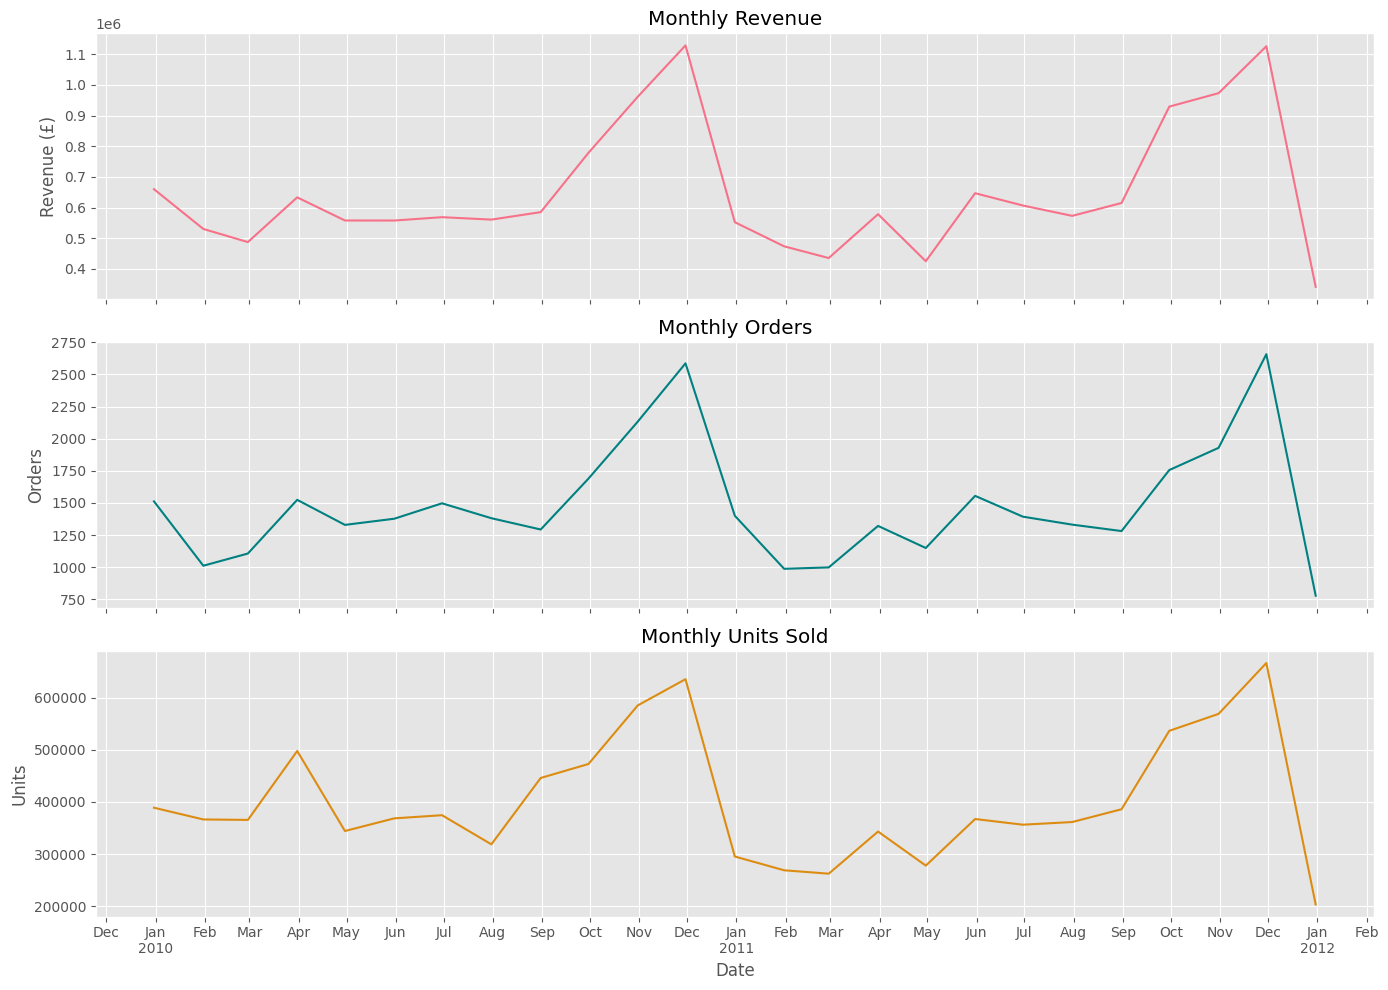

In [215]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14,10),
    sharex=True
)

axes[0].plot(monthly_revenue.index, monthly_revenue.values)
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Revenue (£)")

axes[1].plot(monthly_orders.index, monthly_orders.values, color="teal")
axes[1].set_title("Monthly Orders")
axes[1].set_ylabel("Orders")

axes[2].plot(monthly_quantity.index, monthly_quantity.values, color="#DD8C12")
axes[2].set_title("Monthly Units Sold")
axes[2].set_ylabel("Units")
axes[2].set_xlabel("Date")

def formatter(x, pos):
    date = mdates.num2date(x)

    if date.month == 1:
        return f"Jan\n{date.year}"
    return date.strftime("%b")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(formatter))

plt.tight_layout()
plt.show()

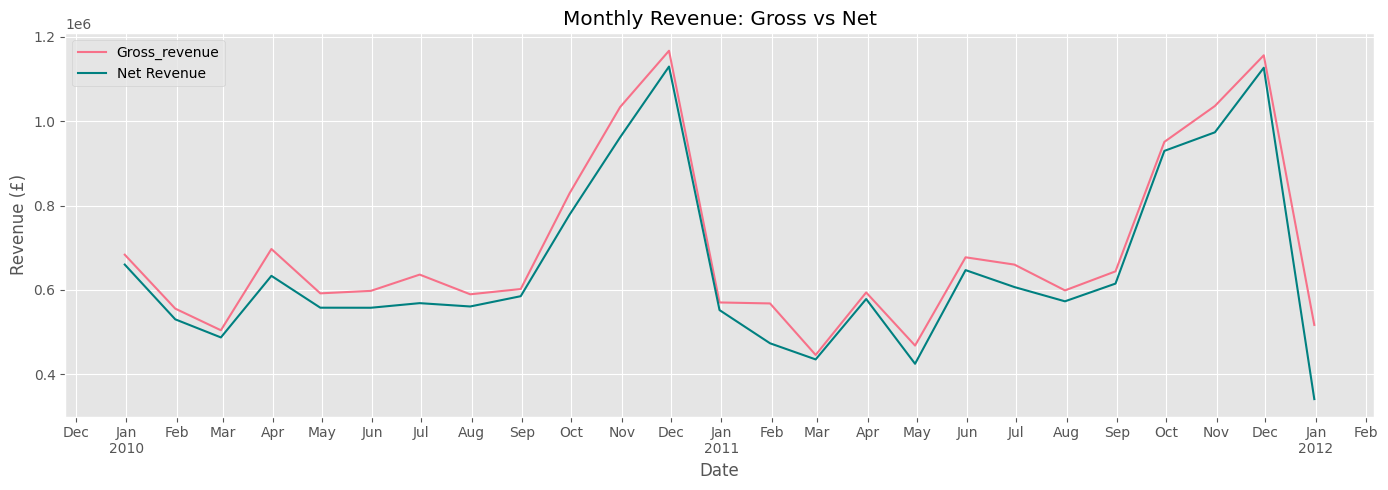

In [216]:
# Revenue bruto (sin cancelaciones) VS revenue neto (con cancelaciones)

revenue_gross = (
    df_sales.set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
)

revenue_net = (
    df.set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
)

plt.figure(figsize=(14,5))

plt.plot(revenue_gross.index, revenue_gross.values,
    label="Gross_revenue",
)

plt.plot(revenue_net.index, revenue_net.values,
    label="Net Revenue",
    color="teal"
)

ax = plt.gca()
# Un tick por mes
ax.xaxis.set_major_locator(mdates.MonthLocator())
# Meses + año en enero
ax.xaxis.set_major_formatter(FuncFormatter(formatter))

plt.title("Monthly Revenue: Gross vs Net")
plt.ylabel("Revenue (£)")
plt.xlabel("Date")
plt.legend()

plt.tight_layout()
plt.show()

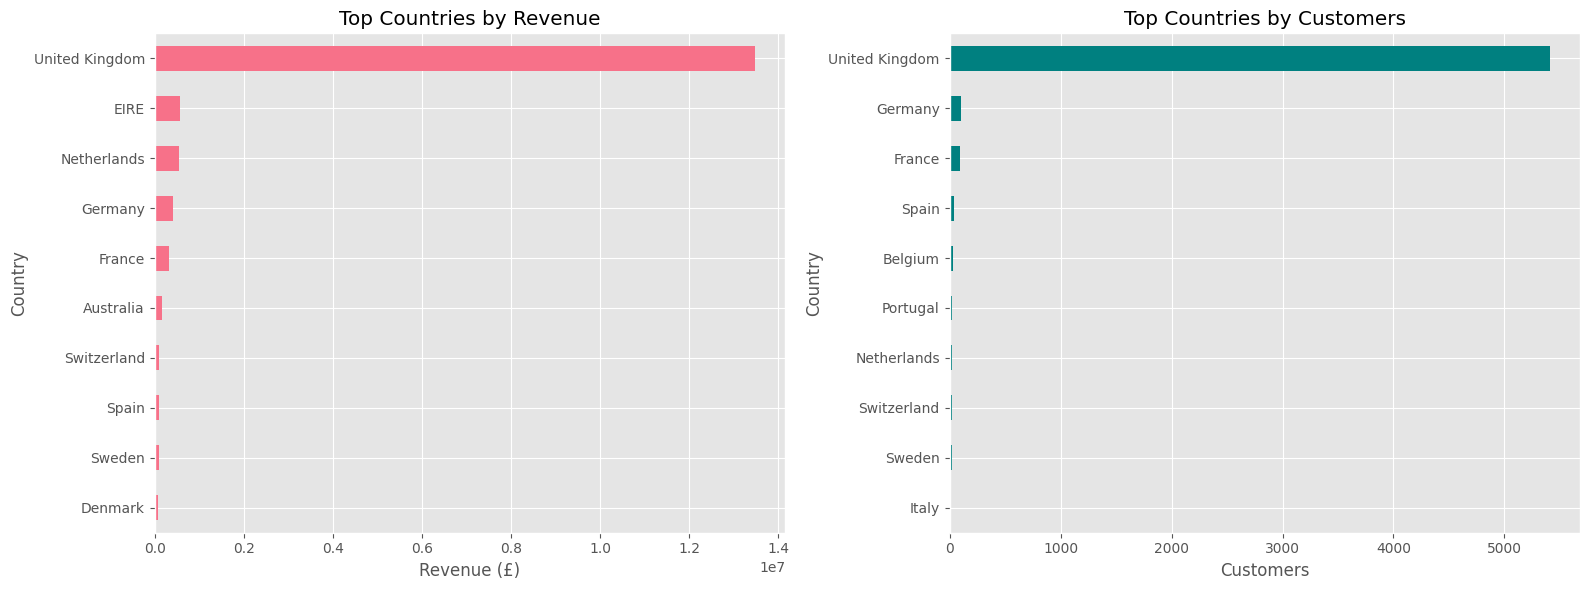

UK representa el 82.76% del revenue total


In [225]:
# Análisis geográfico (Top países por revenue y por número de clientes)

# Revenue neto por país
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
)

# Nº de clientes por país
country_customers = (
    df.groupby("Country")["Customer ID"]
    .nunique()
)


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Revenue
country_revenue.sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh",
    ax=axes[0],
)

axes[0].set_title("Top Countries by Revenue")
axes[0].set_xlabel("Revenue (£)")
axes[0].set_ylabel("Country")

# Customers
country_customers.sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="teal"
)

axes[1].set_title("Top Countries by Customers")
axes[1].set_xlabel("Customers")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()

print(f"UK representa el {country_revenue.max()/country_revenue.sum()*100 :.2f}% del revenue total")


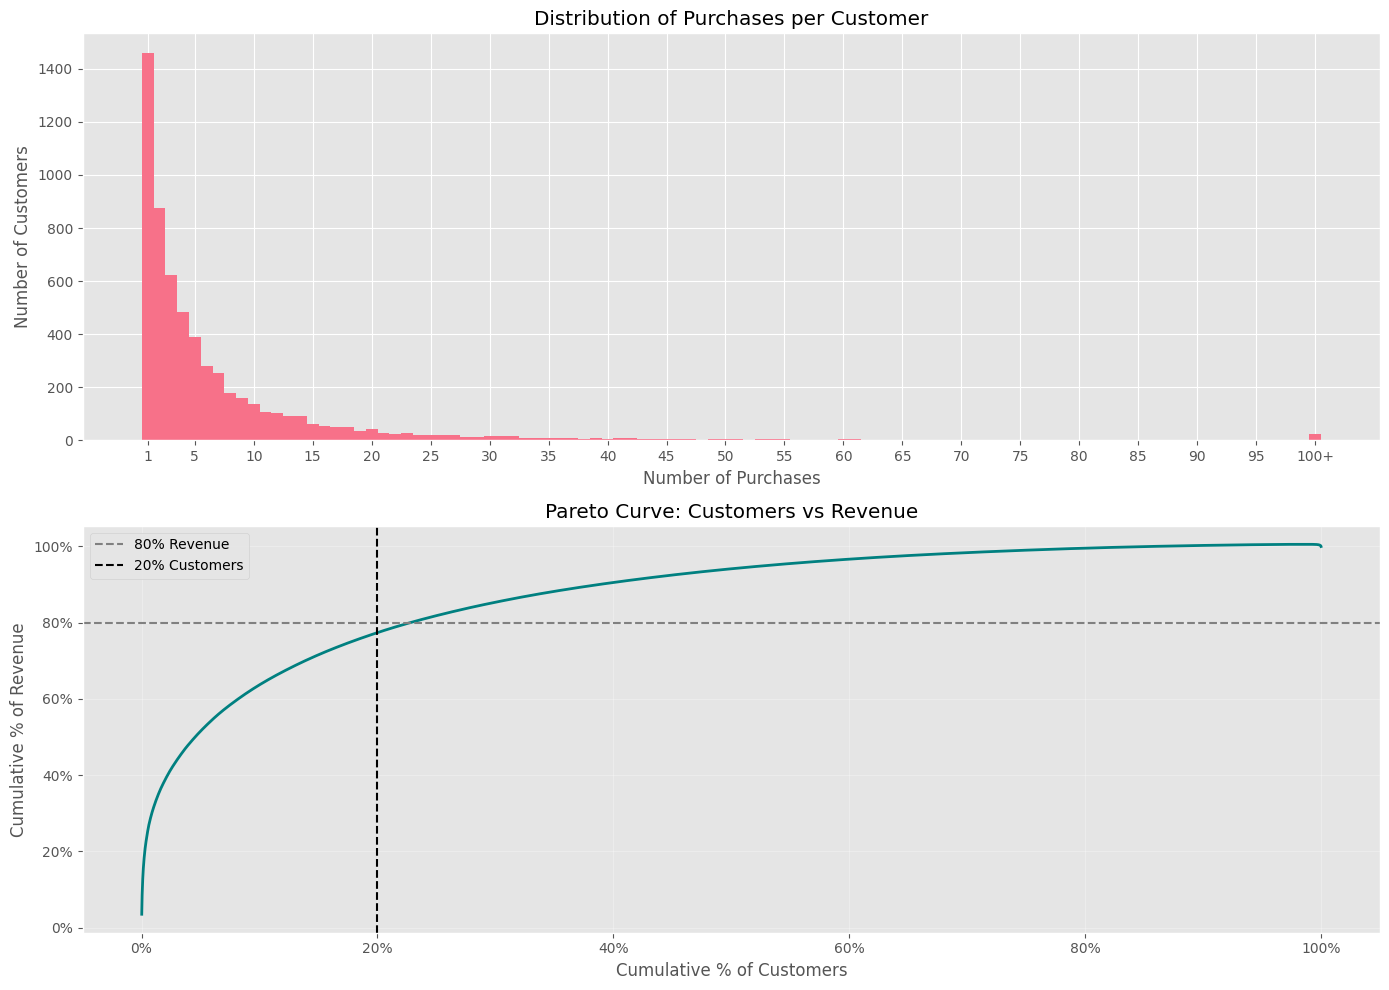

In [218]:
from matplotlib.ticker import PercentFormatter

# Distribución de compras
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
)

customer_orders_binned = customer_orders.clip(upper=100)

orders_dist = (
    customer_orders_binned
      .value_counts()
      .sort_index()
)

# Curva de Pareto (visualizar la distribucion del revenue entre los clientes mediante pct acumulado)
customer_rev = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

cum_customers = (
    np.arange(1, len(customer_rev) + 1)
    / len(customer_rev)
)

cum_revenue = (
    customer_rev.cumsum()
    / customer_rev.sum()
)


# Visualización
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 10)
)

# Gráfico 1
x = orders_dist.index.astype(int)

axes[0].bar(
    x,
    orders_dist.values,
    width=1.0,
)

axes[0].set_title("Distribution of Purchases per Customer")
axes[0].set_xlabel("Number of Purchases")
axes[0].set_ylabel("Number of Customers")

ticks = [1] + list(range(5, 101, 5))
labels = [str(t) for t in ticks]
labels[-1] = "100+"

axes[0].set_xticks(ticks)
axes[0].set_xticklabels(labels)

# Gráfico 2
axes[1].plot(
    cum_customers,
    cum_revenue,
    linewidth=2,
    color="teal"
)

axes[1].axhline(
    0.8,
    linestyle="--",
    color="gray",
    label="80% Revenue"
)

axes[1].axvline(
    0.2,
    linestyle="--",
    color="black",
    label="20% Customers"
)

axes[1].set_title("Pareto Curve: Customers vs Revenue")
axes[1].set_xlabel("Cumulative % of Customers")
axes[1].set_ylabel("Cumulative % of Revenue")

axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

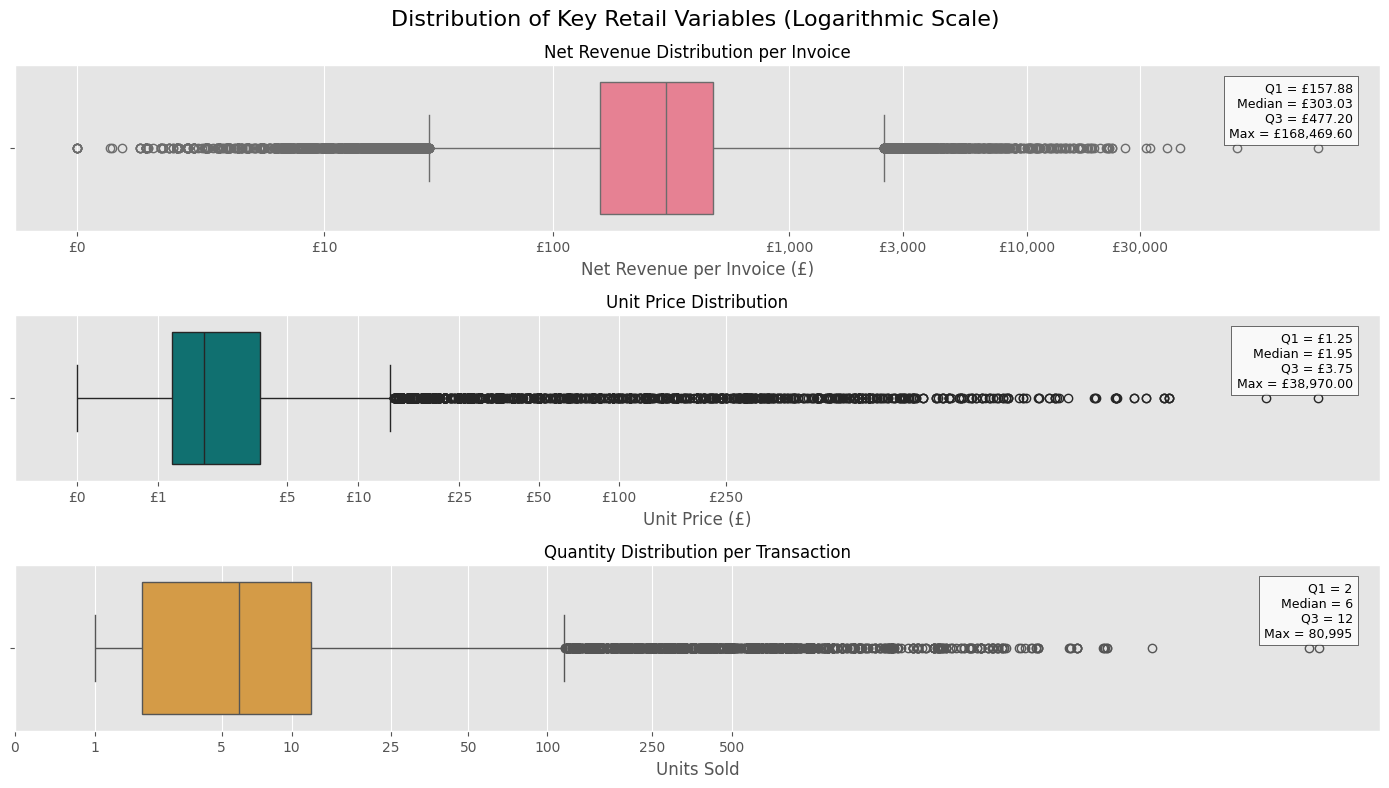

In [ ]:
# Revenue por factura
invoice_revenue = (
    df_sales.groupby("Invoice")["Revenue"]
    .sum()
)

# Crear figura
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 8)
)

sns.boxplot(
    x=np.log1p(invoice_revenue),
    ax=axes[0],
)

axes[0].set_title(
    "Net Revenue Distribution per Invoice",
    fontsize=12,
)

axes[0].set_xlabel("Net Revenue per Invoice (£)")

revenue_labels = [
    0,
    10,
    100,
    1000,
    3000,
    10000,
    30000
]

axes[0].set_xticks(np.log1p(revenue_labels))
axes[0].set_xticklabels(
    [f"£{x:,}" for x in revenue_labels]
)

# Cuantiles
q1 = invoice_revenue.quantile(0.25)
q2 = invoice_revenue.quantile(0.50)
q3 = invoice_revenue.quantile(0.75)
max_val = invoice_revenue.max()

axes[0].text(
    0.98,
    0.90,
    f"Q1 = £{q1:,.2f}\n"
    f"Median = £{q2:,.2f}\n"
    f"Q3 = £{q3:,.2f}\n"
    f"Max = £{max_val:,.2f}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)



# Precio unitario
sns.boxplot(
    x=np.log1p(df["Price"]),
    ax=axes[1],
    color="teal"
)

axes[1].set_title(
    "Unit Price Distribution",
    fontsize=12,
)
axes[1].set_xlabel("Unit Price (£)")

price_labels = [
    0,
    1,
    5,
    10,
    25,
    50,
    100,
    250
]

axes[1].set_xticks(np.log1p(price_labels))
axes[1].set_xticklabels(
    [f"£{x}" for x in price_labels]
)

# Cuantiles
q1 = df["Price"].quantile(0.25)
q2 = df["Price"].quantile(0.50)
q3 = df["Price"].quantile(0.75)
max_val = df["Price"].max()

axes[1].text(
    0.98,
    0.90,
    f"Q1 = £{q1:,.2f}\n"
    f"Median = £{q2:,.2f}\n"
    f"Q3 = £{q3:,.2f}\n"
    f"Max = £{max_val:,.2f}",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)


# Cantidad por transacción
sns.boxplot(
    x=np.log1p(df_sales["Quantity"]),
    ax=axes[2],
    color="#ECA02F"
)

axes[2].set_title(
    "Quantity Distribution per Transaction",
    fontsize=12,
)

axes[2].set_xlabel("Units Sold")

quantity_labels = [
    0,
    1,
    5,
    10,
    25,
    50,
    100,
    250,
    500
]

axes[2].set_xticks(np.log1p(quantity_labels))
axes[2].set_xticklabels(
    [f"{x:,}" for x in quantity_labels]
)

# Cuantiles
q1 = df_sales["Quantity"].quantile(0.25)
q2 = df_sales["Quantity"].quantile(0.50)
q3 = df_sales["Quantity"].quantile(0.75)
max_val = df_sales["Quantity"].max()

axes[2].text(
    0.98,
    0.90,
    f"Q1 = {round(q1):,}\n"
    f"Median = {round(q2):,}\n"
    f"Q3 = {round(q3):,}\n"
    f"Max = {round(max_val):,}",
    transform=axes[2].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)



# Título general
fig.suptitle(
    "Distribution of Key Retail Variables (Logarithmic Scale)",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [107]:
def percentile_outliers (df, col: str, var: float = 0.05):
    lower = df[col].quantile(var)
    upper = df[col].quantile(1-var)
    df_percent= df.copy(deep=True)
    df_percent ["lower"] = lower
    df_percent["upper"] = upper
    outliers = df_percent[((df_percent [col] < lower) | (df_percent[col] > upper))]
    return outliers[[col, 'lower', 'upper']]

def IQR_outliers (df, col: str):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df_IQR = df.copy(deep=True)
    df_IQR["lower"] = lower
    df_IQR["upper"] = upper
    outliers = df_IQR[((df_IQR[col] < lower) | (df_IQR [col] > upper))]
    return outliers [[col, 'lower', 'upper']]

def zscore_outliers (df, col: str):
    mean = np.mean (df[col])
    std= np.std(df[col])
    df_zscore = df.copy(deep=True)
    df_zscore['z-score'] = (df_zscore[col] - mean) / std
    outliers = df_zscore[abs(df_zscore['z-score']) > 3]
    return outliers [[col, 'z-score']]

In [108]:
def outlier_report(df, col):
    outliers = IQR_outliers(df, col)

    pct_rows = (
        len(outliers)
        / len(df)
        * 100
    )

    print("", col)
    print(f"Outliers: {len(outliers):,}")
    print(f"% Rows: {pct_rows:.2f}%")

outlier_report(df_sales, "Quantity")
print()
outlier_report(df, "Price")
print()
outlier_report(df_sales, "Revenue")

# Se detectó entre un 6% y un 8% de outliers en las variables analizadas. 
# Al considerar que reflejan operaciones reales del negocio y no errores de calidad de datos, seguramente por la presencia de clientes mayoristas que justifica la existencia
# de compras, precios e importes significativamente superiores a la media. Se ha tomado la decisión de mantener estos datos en el modelado y únicamente se trataron durante
# la visualización para mejorar la interpretabilidad de los gráficos.

 Quantity
Outliers: 51,129
% Rows: 6.56%

 Price
Outliers: 69,161
% Rows: 8.67%

 Revenue
Outliers: 63,561
% Rows: 8.15%


## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [109]:
# Necesitamos agrupar por factura para operar sobre el revenue de cada factura completa sumando el revenue de las lineas de detalle
# La agrupación se hace sobre "df_sales" (df sin cancelaciones) puesto que no queremos incluir los tickets cancelados como nuevas compras ni que los valores negativos influyan en los cálculos estadísticos
invoice_summary = (
    df_sales.groupby(["Customer ID", "Invoice"])
    .agg(InvoiceRevenue=("Revenue", "sum"))
    .reset_index()
)
# Si intentamos hacer la media sobre las filas sin agrupar por factura, realmente sera la media de las lineas de detalle de las facturas, es decir,
# revenue de linea de detalle medio, no revenue de ticket medio

customer_summary = (
    invoice_summary
    .groupby("Customer ID")
    .agg(
        TotalRevenue=("InvoiceRevenue", "sum"),
        NumPurchases=("Invoice", "nunique"),
        AvgTicket=("InvoiceRevenue", "mean"),
        MaxTicket=("InvoiceRevenue", "max"),
        MinTicket=("InvoiceRevenue", "min")
    )
    .reset_index()
)

customer_summary.describe()

,Customer ID,TotalRevenue,NumPurchases,AvgTicket,MaxTicket,MinTicket
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,2954.302401,6.287196,384.973962,679.044315,210.759606
std,1715.429759,14436.758822,13.012879,1213.996783,2785.204593,386.061086
min,12346.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,13833.000000,341.900000,1.000000,176.627143,231.790000,66.750000
50%,15313.000000,865.600000,3.000000,279.129091,384.270000,138.830000
75%,16797.000000,2247.720000,7.000000,414.895714,662.200000,273.350000
max,18287.000000,580987.040000,398.000000,84236.250000,168469.600000,11880.840000


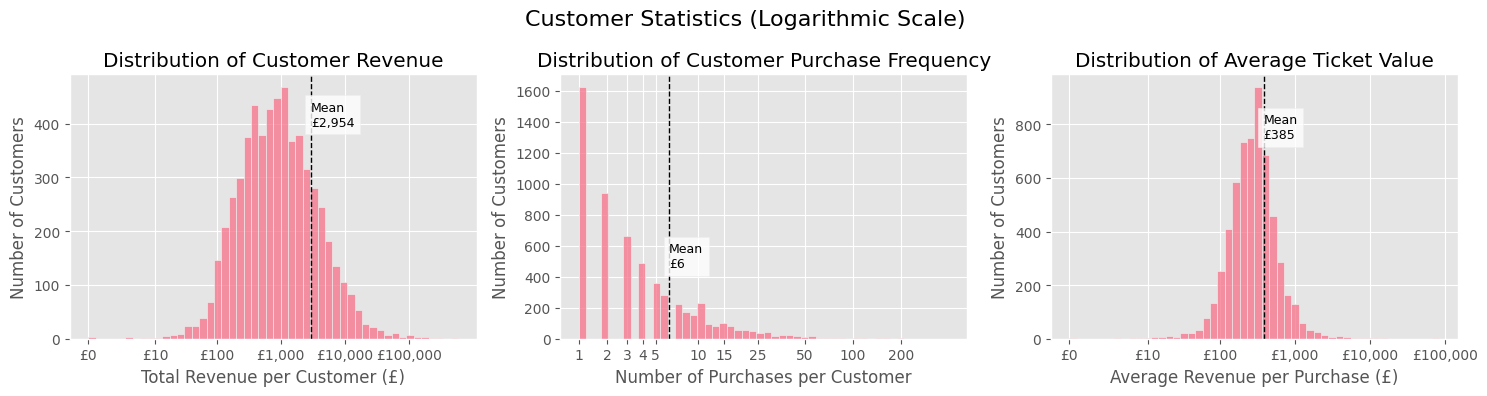

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: Revenue por cliente
sns.histplot(
    np.log1p(customer_summary["TotalRevenue"]),
    bins=50,
    ax=axes[0]
)

axes[0].set_title("Distribution of Customer Revenue")
axes[0].set_xlabel("Total Revenue per Customer (£)")
axes[0].set_ylabel("Number of Customers")

revenue_labels = [
    0,
    10,
    100,
    1000,
    10000,
    100000
]

axes[0].set_xticks(np.log1p(revenue_labels))
axes[0].set_xticklabels([f"£{x:,}" for x in revenue_labels])

# media
mean_revenue = customer_summary["TotalRevenue"].mean()
mean_pos = np.log1p(mean_revenue)
axes[0].axvline(
    mean_pos,
    color="black",
    linestyle="--",
    linewidth=1
)
axes[0].text(
    mean_pos,
    axes[0].get_ylim()[1] * 0.9,
    f"Mean\n£{mean_revenue:,.0f}",
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8
    )
)

# Gráfica 2: Compras por cliente
sns.histplot(
    np.log1p(customer_summary["NumPurchases"]),
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Distribution of Customer Purchase Frequency")
axes[1].set_xlabel("Number of Purchases per Customer")
axes[1].set_ylabel("Number of Customers")

purchase_labels = [
    1,
    2,
    3,
    4,
    5,
    10,
    15,
    25,
    50,
    100,
    200
]

axes[1].set_xticks(np.log1p(purchase_labels))
axes[1].set_xticklabels(purchase_labels)

# media
mean_purchases = customer_summary["NumPurchases"].mean()
mean_pos = np.log1p(mean_purchases)
axes[1].axvline(
    mean_pos,
    color="black",
    linestyle="--",
    linewidth=1
)
axes[1].text(
    mean_pos,
    axes[0].get_ylim()[1] * 0.9,
    f"Mean\n£{mean_purchases:,.0f}",
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8
    )
)

# Gráfica 3: Dsitribución de ticket medio
sns.histplot(
    np.log1p(customer_summary["AvgTicket"]),
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Distribution of Average Ticket Value")
axes[2].set_xlabel("Average Revenue per Purchase (£)")
axes[2].set_ylabel("Number of Customers")

axes[2].set_xticks(np.log1p(revenue_labels))
axes[2].set_xticklabels([f"£{x:,}" for x in revenue_labels])

# media
mean_ticket = customer_summary["AvgTicket"].mean()
mean_pos = np.log1p(mean_ticket)
axes[2].axvline(
    mean_pos,
    color="black",
    linestyle="--",
    linewidth=1
)
axes[2].text(
    mean_pos,
    axes[0].get_ylim()[1] * 1.5,
    f"Mean\n£{mean_ticket:,.0f}",
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(
        facecolor="white",
        alpha=0.8
    )
)

# Título general
fig.suptitle(
    "Customer Statistics (Logarithmic Scale)",
    fontsize=16,
)

plt.tight_layout()

# Las variables Revenue y Average Ticket Value presentan una distribución fuertemente sesgada hacia la derecha debido a la existencia de clientes de alto valor.
# Pero tras aplicar una transformación logarítmica (log1p) en la visualización, ambas distribuciones adoptan una forma aproximadamente normal, lo que sugiere
# que siguen un comportamiento log-normal característico de variables económicas y de consumo.

## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

In [111]:
# Para el modelo usaremos "df_sales" (df sin cancelaciones, solo las ventas) puesto que no pretendemos distinguir si las cancelaciones de algún cliente influye en su decisión de volver
# a comprar, y por lo tanto, usaremos solo los datos de ventas

df_sales.info()
df_sales.sample(10)

<class 'pandas.DataFrame'>
Index: 779493 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779493 non-null  string        
 1   StockCode    779493 non-null  string        
 2   Quantity     779493 non-null  int64         
 3   InvoiceDate  779493 non-null  datetime64[us]
 4   Price        779493 non-null  float64       
 5   Customer ID  779493 non-null  int64         
 6   Country      779493 non-null  string        
 7   Revenue      779493 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), string(3)
memory usage: 53.5 MB


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
763570,557898,21987,12,2011-06-23 14:35:00,0.65,17314,United Kingdom,7.80
27965,491722,21213,48,2009-12-13 16:12:00,0.55,16551,United Kingdom,26.40
413083,528892,21485,3,2010-10-25 12:42:00,4.95,13050,United Kingdom,14.85
834339,564056,90082A,3,2011-08-22 14:13:00,6.35,14387,United Kingdom,19.05
550985,538371,21809,2,2010-12-12 11:07:00,1.25,15570,United Kingdom,2.50
8431,490078,35004C,3,2009-12-03 15:09:00,5.45,17853,United Kingdom,16.35
161969,504873,21541,12,2010-04-18 12:36:00,0.85,14817,United Kingdom,10.20
339474,522465,22327,6,2010-09-15 08:43:00,2.95,16155,United Kingdom,17.70
247591,513335,84991,24,2010-06-24 09:49:00,0.55,17686,United Kingdom,13.20
91132,497954,22315,4,2010-02-15 12:50:00,1.25,16225,United Kingdom,5.00


In [116]:
min_date = df_sales["InvoiceDate"].min().date()
max_date = df_sales["InvoiceDate"].max().date()

margin_days = (max_date - min_date).days

margin_months = (
    (max_date.year - min_date.year) * 12
    + (max_date.month - min_date.month)
)

print(f"Fecha mínima: {min_date}")
print(f"Fecha máxima: {max_date}")
print(f"Margen histórico: {margin_days} días ({margin_months} meses)")

# Datos durante 21 meses para construir variables por cliente y margen de 3 meses para etiquetar (para predecir si un cliente comprará en los próximos 3 meses)
cutoff_date = df_sales["InvoiceDate"].max() - pd.DateOffset(months=3)

Fecha mínima: 2009-12-01
Fecha máxima: 2011-12-09
Margen histórico: 738 días (24 meses)


In [117]:
# Separamos las ventas 
df_history = df_sales[
    df_sales["InvoiceDate"] < cutoff_date
].copy()

df_future = df_sales[
    df_sales["InvoiceDate"] >= cutoff_date
].copy()

In [139]:
# Clientes que compran después del corte
future_customers = set(
    df_future["Customer ID"].unique()
)

# tabla de clientes históricos
df_model = pd.DataFrame({
    "Customer ID":
        df_history["Customer ID"].unique()
})

# Target (1 si vuelven a aparecer, 0 si no)
df_model["Target"] = (
    df_model["Customer ID"]
    .isin(future_customers)
    .astype(int)
)

# Visualizar balance
df_model["Target"].value_counts()

Target
0    2987
1    2294
Name: count, dtype: int64

In [140]:
# Recency: dias desde la última compra anterior a la fecha de corte
recency = (
    df_history.groupby("Customer ID")
    ["InvoiceDate"]
    .max()
)

recency = (
    cutoff_date - recency
).dt.days

In [141]:
# Frequency: número de compras realizadas hasta la fecha de corte
frequency = (
    df_history.groupby("Customer ID")
    ["Invoice"]
    .nunique()
)

In [142]:
# Monetary: revenue del cliente hasta la fecha de corte
monetary = (
    df_history.groupby("Customer ID")
    ["Revenue"]
    .sum()
)

In [143]:
# Ticket medio por cliente
avg_ticket = (
    monetary / frequency
)

In [144]:
df_model = df_model.merge(recency.rename("Recency"), on="Customer ID")

df_model.sample(5)

,Customer ID,Target,Recency
4933,15163,1,100
2274,13388,0,39
3180,16417,0,401
1308,13583,0,64
4832,12886,1,128


In [145]:
df_model = df_model.merge(frequency.rename("Frequency"), on="Customer ID")

df_model.sample(5)

,Customer ID,Target,Recency,Frequency
792,15838,1,17,27
2696,17741,0,315,2
1566,13842,1,64,16
1699,16913,0,198,3
4433,12502,0,4,5


In [146]:
df_model = df_model.merge(monetary.rename("Monetary"), on="Customer ID")

df_model.sample(5)

,Customer ID,Target,Recency,Frequency,Monetary
4158,13124,1,160,3,3401.80
165,14080,1,321,4,1070.08
3138,13435,1,18,5,1725.56
1944,15775,0,153,2,150.50
2206,14758,0,53,7,2864.97


In [147]:
df_model = df_model.merge(avg_ticket.rename("AvgTicket"), on="Customer ID")

df_model.sample(5)

,Customer ID,Target,Recency,Frequency,Monetary,AvgTicket
4900,16813,1,5,7,1146.84,163.834286
2924,14566,0,19,4,4092.00,1023.000000
1234,13971,1,14,12,3895.21,324.600833
480,13042,0,506,3,1488.59,496.196667
3976,13500,1,31,2,625.93,312.965000


In [172]:
countries_per_customer = (
    df_sales.groupby("Customer ID")["Country"]
    .agg(
        countries="unique",
        n_countries="nunique"
    )
    .sort_values("n_countries", ascending=False)
)

print(countries_per_customer.describe())
print(f"% de clientes con varios paises: {(len(countries_per_customer[countries_per_customer["n_countries"] > 1]) / len(countries_per_customer) * 100) :.2f}%")

# Nos quedamos con el país men el que el cliente a comprado con mayor frecuencia (moda) porque el máximo de paises por cliente es 2
country = (
    df_history
    .groupby("Customer ID")["Country"]
    .agg(lambda x: x.mode().iloc[0])
)

       n_countries
count  5881.000000
mean      1.002211
std       0.046968
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
% de clientes con varios paises: 0.22%


In [ ]:
df_model = df_model.merge(
    country.rename("Country"),
    on="Customer ID"
)

<class 'pandas.DataFrame'>
RangeIndex: 5281 entries, 0 to 5280
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5281 non-null   int64  
 1   Target       5281 non-null   int64  
 2   Recency      5281 non-null   int64  
 3   Frequency    5281 non-null   int64  
 4   Monetary     5281 non-null   float64
 5   AvgTicket    5281 non-null   float64
 6   Country      5281 non-null   string 
dtypes: float64(2), int64(4), string(1)
memory usage: 288.9 KB


In [179]:
df_model.info()

countries_per_customer = (
    df_model.groupby("Customer ID")["Country"]
    .agg(
        countries="unique",
        n_countries="nunique"
    )
    .sort_values("n_countries", ascending=False)
)

print()
print(countries_per_customer.describe())
print(f"% de clientes con varios paises: {(len(countries_per_customer[countries_per_customer["n_countries"] > 1]) / len(countries_per_customer) * 100) :.2f}%")

<class 'pandas.DataFrame'>
RangeIndex: 5281 entries, 0 to 5280
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5281 non-null   int64  
 1   Target       5281 non-null   int64  
 2   Recency      5281 non-null   int64  
 3   Frequency    5281 non-null   int64  
 4   Monetary     5281 non-null   float64
 5   AvgTicket    5281 non-null   float64
 6   Country      5281 non-null   string 
dtypes: float64(2), int64(4), string(1)
memory usage: 288.9 KB

       n_countries
count       5281.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
% de clientes con varios paises: 0.00%


In [ ]:
# Separamos X e y, y eliminamos las columnas "Customer ID" y "Target" porque target es el objetivo a predecir y Customer ID no es una variable útil para el entrenamiento

X = df_model.drop(
    columns=["Customer ID", "Target"]
)

y = df_model["Target"]

X.columns

Index(['Recency', 'Frequency', 'Monetary', 'AvgTicket', 'Country'], dtype='str')

In [185]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [192]:
# Construimos preprocesador para escalar las variables numericas (Recency, Frequency, Monetary y AvgTicket) y discretizar las categoricas (Country)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            ["Recency" ,"Frequency" ,"Monetary" ,"AvgTicket"]
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first" # Se puede contruir como combinacion lineal del resto de variables
            ),
            ["Country"]
        )
    ]
)

In [193]:
# Construimos el pipeline
pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [194]:
# Entrenamiento
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Recency','Frequency','Monetary','AvgTicket','Country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns

In [195]:
# Predicciones

# Predicción de la probabilidad de que el cliente recompre
y_proba = pipeline.predict_proba(
    X_test
)[:, 1]

# Predicción del cliente sobre la recompra
y_pred = pipeline.predict(
    X_test
)

d:\Ferran\Formacion\Evolve\data_science\machine_learning\ml_venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Ferran\Formacion\Evolve\data_science\machine_learning\ml_venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [196]:
# AUC
auc = roc_auc_score(
    y_test,
    y_proba
)

print(f"AUC: {auc:.4f}")

AUC: 0.7861


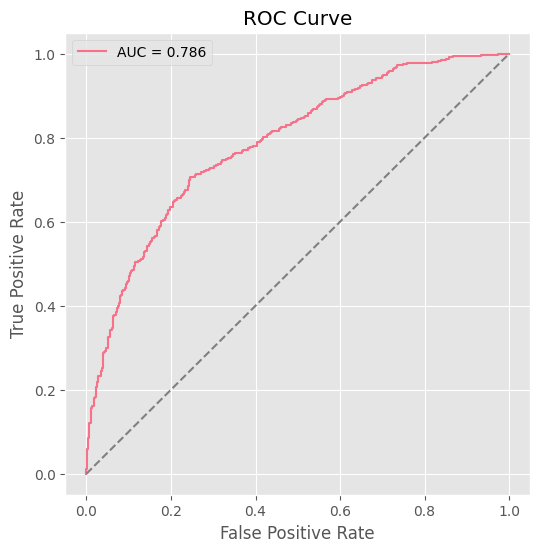

In [197]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [201]:
# Es posible que las variables Monetary y AvgTicket, como hemos visto anteriormente en las gráficas, son fuertemente asimétricas
# por lo que se decide reentrenar el modelo aplicando una transformación logaritmica sobre estas variables para tratar de mejorar el resultado

df_model_log = df_model

df_model_log["Monetary"] = np.log1p(df_model["Monetary"])
df_model_log["AvgTicket"] = np.log1p(df_model["AvgTicket"])

In [203]:
# Repetimeos el entrenamiento

# Separamos X e y
X = df_model_log.drop(columns=["Customer ID", "Target"])
y = df_model_log["Target"]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(
    X_train,
    y_train
)

# Predicciones
y_proba_log = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

# AUC
auc_log = roc_auc_score(
    y_test,
    y_proba_log
)
print(f"AUC: {auc:.4f}\nAUC (log): {auc_log:.4f}")

AUC: 0.7861
AUC (log): 0.7924


d:\Ferran\Formacion\Evolve\data_science\machine_learning\ml_venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Ferran\Formacion\Evolve\data_science\machine_learning\ml_venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


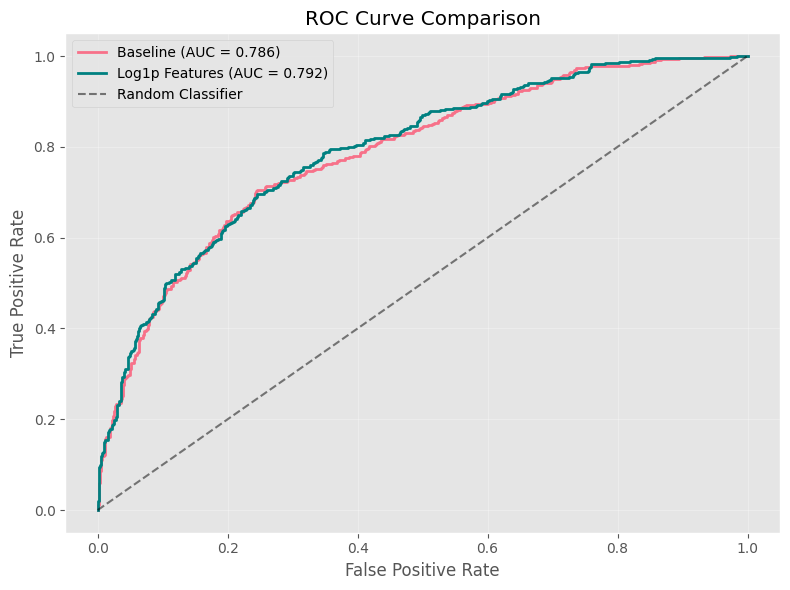

In [221]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_proba_log
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Baseline (AUC = {auc:.3f})"
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    color="teal",
    label=f"Log1p Features (AUC = {auc_log:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    alpha=0.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



In [205]:
# Accedemos a la regresion logística y obtenemos los nombres de las variables
model = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Obtenemos los coeficientes y los unimos a las variables correspondientes
importance = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_[0]
})

# No importa el signo en el peso de la variable asi que calculamos su absoluto y mostramos las 10 con mayor peso
importance["abs_coef"] = importance["coef"].abs()
importance.sort_values("abs_coef", ascending=False).head(10)

,feature,coef,abs_coef
11,cat__Country_Denmark,1.625245,1.625245
40,cat__Country_Unspecified,-0.879271,0.879271
27,cat__Country_Norway,0.801357,0.801357
2,num__Monetary,0.770272,0.770272
7,cat__Country_Canada,-0.769609,0.769609
0,num__Recency,-0.753862,0.753862
17,cat__Country_Greece,-0.743979,0.743979
33,cat__Country_Spain,0.624311,0.624311
37,cat__Country_USA,-0.601175,0.601175
12,cat__Country_EIRE,-0.570133,0.570133


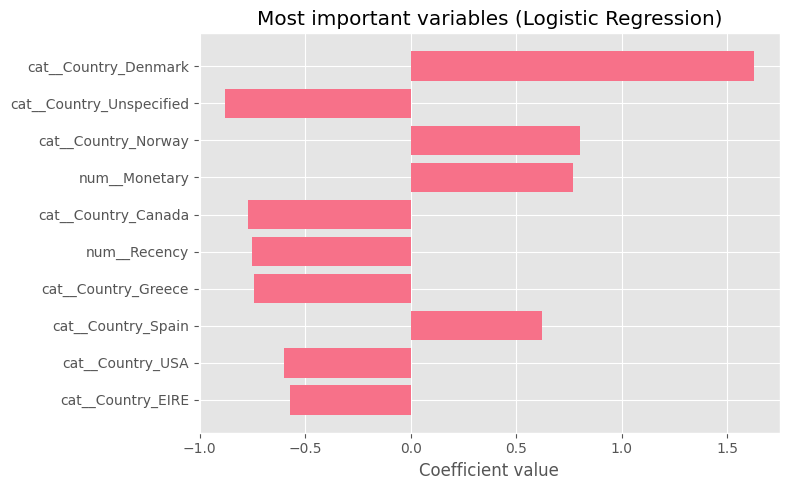

In [ ]:
top_features = importance.sort_values(
    "abs_coef",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["feature"],
    top_features["coef"]
)

plt.title("Most important variables (Logistic Regression)")
plt.xlabel("Coefficient value")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# El modelo muestra que la variable geográfica tiene un impacto relevante en la probabilidad de recompra, destacando países como Dinamarca y Noruega con coeficientes positivos,
# lo que indica una mayor probabilidad de recompra en comparación con el resto de países del dataset.

# Asimismo, la variable Monetary (gasto total del cliente en escala logarítmica) presenta un efecto positivo, lo que sugiere que los clientes con mayor volumen de gasto histórico
# tienden a presentar mayor recurrencia de compra.

# Por el contrario, países como Canadá, Grecia y Estados Unidos muestran coeficientes negativos, indicando una menor probabilidad relativa de recompra dentro del modelo.

# Finalmente, la variable Recency presenta un efecto negativo, lo cual es consistente con el comportamiento esperado en retail: cuanto más tiempo ha pasado desde la última compra,
# menor es la probabilidad de que el cliente vuelva a comprar.